# TEAL Graph Exploration

Build a NetworkX `MultiDiGraph` straight from TEAL source, walk it with standard NetworkX ops, and render slices with Graphviz `dot`.

**Dependencies:** `networkx`, `dot` (Graphviz) on PATH.

Nodes are typed `AstNode` instances (one subclass per TEAL opcode — see `teal_ast.py`), each carrying a `Location` and the opcode's source `code` (with immediates). The first load does a cold run (~20–30s, compiles three queries); subsequent loads hit a per-db CSV cache.

In [1]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path

HERE = Path.cwd()
sys.path.insert(0, str(HERE.parent.parent / "src"))

from tealql.tealtools.graph import load_graph
from tealql.tealtools.viz import (
    cfg_view, to_dot, draw_cfg,
    cfg_bb_graph, to_bb_dot, draw_cfg_bb,
)
from tealql.tealtools.viz.render import BasicBlockNode
# Typed SSA program representation (section 14).
import tealql.tealtools.ssa as teal_ssa
import tealql.tealtools.ast as T
import networkx as nx

## 1. Load a program

Point `load_graph` at any `.teal` source file (or a directory of them) — the graph is reconstructed in-process, nothing to build. Here: the real `xgov` approval program shipped under `tests/contracts/`.

In [2]:
DB = HERE.parent.parent / "tests" / "contracts" / "xgov"
g = load_graph(DB)
g.number_of_nodes(), g.number_of_edges()

(1173, 1202)

## 2. Structure of a node

Each node is an `AstNode` instance. Two fields:

- `.location` — a `Location` dataclass (`file`, `start_line`, `start_column`, `end_line`, `end_column`).
- `.code` — the opcode as written in the source, with its immediates (e.g. `"txn NumAppArgs"`, `"bnz main_l14"`).

The Python *class* encodes the opcode type (`TxnOpcode`, `BnzOpcode`, `IntegerAddOpcode`, ...) and sits in a family hierarchy rooted at `AstNode`. Hash/equality are keyed by `(file, start_line)`.

In [3]:
from itertools import islice

for n in islice(g.nodes, 6):
    print(f"{type(n).__name__:20s}  {n.location.file}:{n.location.start_line:>4}  code={n.code!r}")

Source                approval.teal:   1  code=''
IntcblockOpcode       approval.teal:   2  code='intcblock 0 1 10 3'
BytecblockOpcode      approval.teal:   3  code='bytecblock 0x766f74655f74797065 0x 0x6f75616964 0x766f74655f6964 0x6f7074696f6e5f636f756e7473 0x69735f626f6f747374726170706564 0x766f7465725f636f756e74 0x636c6f73655f74696d65 0x746f74616c5f6f7074696f6e73 0x56 0x736e617073686f745f7075626c69635f6b6579 0x6d657461646174615f697066735f636964 0x73746172745f74696d65 0x656e645f74696d65 0x71756f72756d 0x6e66745f696d6167655f75726c 0x4c6bea72 0x151f7c75 0x6e66745f61737365745f6964 0x068101 0x2c'
TxnOpcode             approval.teal:   4  code='txn NumAppArgs'
Intc0Opcode           approval.teal:   5  code='intc_0'
EqualsComparisonOpcode  approval.teal:   6  code='=='


## 3. Typed filtering via isinstance

Every leaf opcode class subclasses a family (`ArithmeticOpcode`, `BranchOpcode`, `ComparisonOpcode`, `StackManipulationOpcode`, ...) which subclasses `Opcode` which subclasses `AstNode`. Filter by whichever level you want.

In [4]:
from collections import Counter

families = [T.ArithmeticOpcode, T.BranchOpcode, T.ComparisonOpcode,
            T.StackManipulationOpcode, T.TransactionOpcode, T.ScratchSpaceOpcode,
            T.GlobalStateOpcode, T.ControlFlowOpcode]

for fam in families:
    count = sum(1 for n in g if isinstance(n, fam))
    print(f"  {fam.__name__:28s}  {count}")

# Most common leaf types:
print("\nTop 10 leaf classes:")
for cls, k in Counter(type(n).__name__ for n in g).most_common(10):
    print(f"  {cls:28s}  {k}")

  ArithmeticOpcode              42
  BranchOpcode                  72
  ComparisonOpcode              89
  StackManipulationOpcode       125
  TransactionOpcode             60
  ScratchSpaceOpcode            166
  GlobalStateOpcode             82
  ControlFlowOpcode             145

Top 10 leaf classes:
  LoadOpcode                    86
  StoreOpcode                   80
  FrameDigOpcode                77
  Intc0Opcode                   74
  Label                         63
  BytecOpcode                   54
  AssertOpcode                  51
  EqualsComparisonOpcode        50
  PushintOpcode                 36
  AppGlobalGetOpcode            36


## 4. Edge kinds

Every edge has `kind="cfg"` and carries a `successor` label (e.g. `NormalSuccessor`, `BooleanSuccessor(true)`, `RetsubCompletion`). (The extractor-era `dataflow` edge kind is gone — def-use flow now lives in the typed SSA layer, section 14.)

In [5]:
kind_counts = Counter(d["kind"] for _, _, d in g.edges(data=True))
successor_counts = Counter(
    d["successor"] for _, _, d in g.edges(data=True) if d["kind"] == "cfg"
)
print("edges by kind:     ", dict(kind_counts))
print("cfg by successor:  ", dict(successor_counts))

edges by kind:      {'cfg': 1202}
cfg by successor:   {'NormalSuccessor': 1089, 'BooleanSuccessor(true)': 82, 'BooleanSuccessor(false)': 31}


## 5. The CFG view

`cfg_view(g)` returns a read-only subgraph filtered to CFG edges. Any NetworkX algorithm (traversal, paths, components) works on it.

In [6]:
cfg = cfg_view(g)
print("cfg:", cfg.number_of_nodes(), "nodes,", cfg.number_of_edges(), "edges")

cfg: 1172 nodes, 1202 edges


## 6. Walking the graph

Pull every conditional branch (`BnzOpcode` / `BzOpcode`) and its CFG successors. `isinstance` against a family class would also work — `T.SimpleConditionalBranches` covers both.

In [7]:
branches = [n for n in g if isinstance(n, (T.BnzOpcode, T.BzOpcode))]
print(f"{len(branches)} conditional branches\n")

for b in branches[:5]:
    print(f"{type(b).__name__} @ L{b.location.start_line}  {b.code!r}")
    for v in cfg.successors(b):
        succ = cfg.get_edge_data(b, v)[0]["successor"]
        print(f"    → L{v.location.start_line:<4} {type(v).__name__:20s} {v.code!r:40s} [{succ}]")

31 conditional branches

BnzOpcode @ L7  'bnz main_l14'
    → L211  Label                'main_l14:'                              [BooleanSuccessor(true)]
    → L8    TxnaOpcode           'txna ApplicationArgs 0'                 [BooleanSuccessor(false)]
BnzOpcode @ L11  'bnz main_l13'
    → L183  Label                'main_l13:'                              [BooleanSuccessor(true)]
    → L12   TxnaOpcode           'txna ApplicationArgs 0'                 [BooleanSuccessor(false)]
BnzOpcode @ L15  'bnz main_l12'
    → L139  Label                'main_l12:'                              [BooleanSuccessor(true)]
    → L16   TxnaOpcode           'txna ApplicationArgs 0'                 [BooleanSuccessor(false)]
BnzOpcode @ L19  'bnz main_l11'
    → L117  Label                'main_l11:'                              [BooleanSuccessor(true)]
    → L20   TxnaOpcode           'txna ApplicationArgs 0'                 [BooleanSuccessor(false)]
BnzOpcode @ L23  'bnz main_l10'
    → L102  Label   

## 7. Shortest CFG path between two opcodes

In [8]:
entry = min(cfg.nodes, key=lambda n: (n.location.file, n.location.start_line))
later = sorted(cfg.nodes, key=lambda n: (n.location.file, n.location.start_line))[50]

try:
    path = nx.shortest_path(cfg, entry, later)
    print(f"L{entry.location.start_line} → L{later.location.start_line}: {len(path)} hops")
    for step in path:
        print(f"  L{step.location.start_line:<4} {type(step).__name__:22s} {step.code!r}")
except nx.NetworkXNoPath:
    print("no path")

L2 → L52: 50 hops
  L2    IntcblockOpcode        'intcblock 0 1 10 3'
  L3    BytecblockOpcode       'bytecblock 0x766f74655f74797065 0x 0x6f75616964 0x766f74655f6964 0x6f7074696f6e5f636f756e7473 0x69735f626f6f747374726170706564 0x766f7465725f636f756e74 0x636c6f73655f74696d65 0x746f74616c5f6f7074696f6e73 0x56 0x736e617073686f745f7075626c69635f6b6579 0x6d657461646174615f697066735f636964 0x73746172745f74696d65 0x656e645f74696d65 0x71756f72756d 0x6e66745f696d6167655f75726c 0x4c6bea72 0x151f7c75 0x6e66745f61737365745f6964 0x068101 0x2c'
  L4    TxnOpcode              'txn NumAppArgs'
  L5    Intc0Opcode            'intc_0'
  L6    EqualsComparisonOpcode '=='
  L7    BnzOpcode              'bnz main_l14'
  L8    TxnaOpcode             'txna ApplicationArgs 0'
  L9    PushbytesOpcode        'pushbytes 0x101cea00'
  L10   EqualsComparisonOpcode '=='
  L11   BnzOpcode              'bnz main_l13'
  L12   TxnaOpcode             'txna ApplicationArgs 0'
  L13   PushbytesOpcode        'pushbytes 0

## 8. Rendering a CFG slice with Graphviz

For 1000+ node graphs the full render is huge. Extract a local neighborhood first, then render that subgraph.

Below: CFG nodes within 6 CFG hops of the program entry.

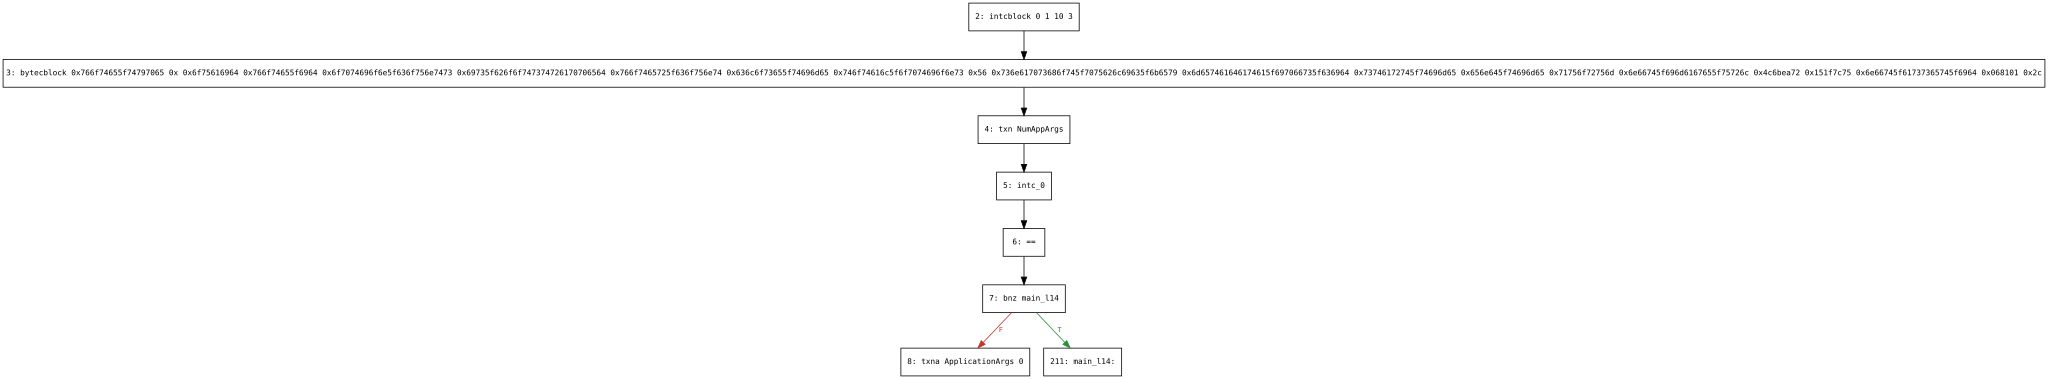

In [9]:
start = entry
near = nx.single_source_shortest_path_length(cfg, start, cutoff=6).keys()
slice_g = g.subgraph(near).copy()

draw_cfg(slice_g)

## 9. Dataflow

There is no graph-level dataflow view anymore — the old extractor emitted `dataflow` edges, the pure-Python pipeline does not. Value flow (def-use, phis, constants) is reconstructed in the typed SSA layer instead: see section 14, in particular `data_graph()` and the `def_chain` walk under *Object-graph navigation*.

## 11. Full-file CFG (for small programs)

For the ~1200-node xgov contract this is huge but legible; for larger contracts prefer slicing first.

In [10]:
files = sorted({n.location.file for n in g.nodes})
print("files:", files)

# Save to disk instead of embedding a huge SVG in the notebook.
import tempfile
svg = draw_cfg(g, file=files[0])
out_path = Path(tempfile.gettempdir()) / f"teal_cfg_{Path(files[0]).stem}.svg"
svg.save(out_path)
print("saved to", out_path)

files: ['approval.teal']


saved to /tmp/teal_cfg_approval.svg


## 11b. Basic-block view

For larger programs the per-opcode CFG is too dense for `dot` to lay out (and often OOMs). `draw_cfg_bb` collapses every basic block into a single rounded box listing its opcodes — small enough for `dot` to render the whole program at once.

In [11]:
h = cfg_bb_graph(g)
bb_count = sum(1 for n in h.nodes if isinstance(n, BasicBlockNode))
print(f"BB graph: {bb_count} basic blocks, {h.number_of_edges()} edges")

# Full file at BB granularity. Save to disk — the SVG is still large.
import tempfile
svg = draw_cfg_bb(g, file=files[0])
out_path_bb = Path(tempfile.gettempdir()) / f"teal_cfg_{Path(files[0]).stem}_bb.svg"
svg.save(out_path_bb)
print("saved to", out_path_bb)

BB graph: 167 basic blocks, 196 edges


saved to /tmp/teal_cfg_approval_bb.svg


## 13. Per-opcode SSA views — superseded

The old graph-attribute API (`stack_inputs` / `stack_outputs` / `print_ssa_trace` / `ssa_functional` on graph nodes) is gone. The same information — typed stack inputs/outputs per opcode, phis included, in functional form — is what `teal_ssa.SSAProgram.functional()` / `functional_by_block()` render in section 14 below.

## 12. Lower-level: raw DOT source

If you want to post-process the DOT (e.g. group nodes by subroutine into clusters), use `to_dot` directly.

In [12]:
dot_src = to_dot(slice_g)
print(dot_src[:500], "...\n")
print("total:", len(dot_src), "bytes")

digraph TEAL {
  rankdir=TB;
  overlap=false;
  splines=true;
  node [shape=box, fontname="Monospace", fontsize=10];
  edge [fontname="Monospace", fontsize=9];
  "approval.teal:2" [label="2: intcblock 0 1 10 3"];
  "approval.teal:3" [label="3: bytecblock 0x766f74655f74797065 0x 0x6f75616964 0x766f74655f6964 0x6f7074696f6e5f636f756e7473 0x69735f626f6f747374726170706564 0x766f7465725f636f756e74 0x636c6f73655f74696d65 0x746f74616c5f6f7074696f6e73 0x56 0x736e617073686f745f7075626c69635f6b6579 0x6d65 ...

total: 1369 bytes


## 14. `teal_ssa` — typed SSA program representation

Everything shown so far lives as node attributes on the NetworkX graph. `teal_ssa.SSAProgram` wraps the same data as first-class Python objects:

- `SSAVar` — one per produced stack value, with back-refs `defined_by` (the `Assignment`) and `uses` (consumers).
- `Phi` — one per live SSA phi (backward-liveness filtered during construction). Carries `args` and `basic_block`.
- `Const` — resolved `intcblock` / `bytecblock` / push-literal value.
- `Assignment` — `outputs = op immediates (inputs)`. Pretty-prints via `.functional(resolve_consts=True/False)`.
- `BasicBlock` — `assignments` (ordered), `phis` (entry phis), `predecessors`, `successors`.

Two graph views: `data_graph()` (data-dependency DAG over SSAVars/Phis/Assignments) and `cfg()` (BB-level NetworkX graph).

In [13]:
from tealql.tealtools.ssa import SSAProgram, Assignment, SSAVar as SSA_SSAVar, Phi, BasicBlock

p = SSAProgram(DB)
print(f"{len(p)} assignments, {len(p.vars)} SSA vars, {len(p.phis)} live phis, {len(p.blocks)} basic blocks")

1109 assignments, 860 SSA vars, 10 live phis, 167 basic blocks


### Per-block functional dump

`functional_by_block` prints each BB as a labeled header (with pred/succ line numbers) followed by its phis and assignments. Great for reading structure at a glance — here, the first `itoa_1` subroutine.

In [14]:
# Filter the per-block dump to the subroutine range we've been exploring.
# (functional_by_block walks *all* BBs in the file — we slice on the output.)
import re
out = p.functional_by_block(file="approval.teal").split("\n\n")
shown = [chunk for chunk in out
         if (m := re.match(r"# BB\(approval\.teal:(\d+)-", chunk))
         and 225 <= int(m.group(1)) <= 260]
print("\n\n".join(shown))

# BB(approval.teal:227-233)  preds=[L249] succs=[L254]
  L 228: proto 1 1 ()
  L 229: V#1@L229 = pushbytes 0x30313233343536373839 ()
  L 230: V#1@L230, V#2@L230, V#3@L230 = frame_dig -1 (0x30313233343536373839, V#1@L252)
  L 231: V#1@L231 = intc_1 ()
  L 232: V#1@L232 = extract3 (1, V#1@L230, V#2@L230)
  L 233: retsub ()

# BB(approval.teal:236-241)  preds=[L256, L641, L663, L732] succs=[L242, L262]
  D_1 = phi(V#1@L259, V#1@L661, V#1@L667, V#1@L734)
  L 237: proto 1 1 ()
  L 238: V#1@L238, V#2@L238 = frame_dig -1 (phi(V#1@L259, V#1@L661, V#1@L667, V#1@L734))
  L 239: V#1@L239 = intc_0 ()
  L 240: V#1@L240 = == (0, V#1@L238)
  L 241: bnz itoa_1_l5 (V#1@L240)

# BB(approval.teal:242-247)  preds=[L236] succs=[L248, L256]
  L 242: V#1@L242, V#2@L242 = frame_dig -1 (V#2@L238)
  L 243: V#1@L243 = intc_2 ()
  L 244: V#1@L244 = / (10, V#1@L242)
  L 245: V#1@L245 = intc_0 ()
  L 246: V#1@L246 = > (0, V#1@L244)
  L 247: bnz itoa_1_l4 (V#1@L246)

# BB(approval.teal:248-248)  preds=[L242] succs=[

### Object-graph navigation

Because each `SSAVar` knows its `defined_by` and `uses`, you can walk backward from a sink or forward from a source. Below: pick the `concat` at L254 and show the transitive def-chain that produced each of its inputs.

In [15]:
from tealql.tealtools.ssa import Const

def def_chain(operand, depth=0, max_depth=4):
    """Print the transitive defining assignment(s) for an operand."""
    indent = "  " * depth
    if isinstance(operand, Const):
        print(f"{indent}{operand!r}")
        return
    if isinstance(operand, Phi):
        print(f"{indent}{operand!r}  (phi at {operand.basic_block})")
        if depth < max_depth:
            for a in operand.args:
                def_chain(a, depth + 1, max_depth)
        return
    # SSAVar
    print(f"{indent}{operand!r}  <-  {operand.defined_by!r}")
    if depth < max_depth and operand.defined_by is not None:
        for inp in operand.defined_by.inputs:
            def_chain(inp, depth + 1, max_depth)

# Pick the concat at L254 — its inputs are two phis (one nested indirect).
concat = next(a for a in p if a.location.file == "approval.teal"
              and a.location.line == 254 and a.op == "concat")
print(f"{concat!r}\n")
for i, inp in enumerate(concat.inputs, start=1):
    print(f"input {i}:")
    def_chain(inp, depth=1)
    print()

V#1@L254 = concat (V#1@L232, V#1@L252)

input 1:
  V#1@L232  <-  V#1@L232 = extract3 (1, V#1@L230, V#2@L230)
    V#1@L231  <-  V#1@L231 = intc_1 ()
    V#1@L230  <-  V#1@L230, V#2@L230, V#3@L230 = frame_dig -1 (0x30313233343536373839, V#1@L252)
      V#1@L229  <-  V#1@L229 = pushbytes 0x30313233343536373839 ()
      V#1@L252  <-  V#1@L252 = % (10, V#1@L250)
        V#1@L251  <-  V#1@L251 = intc_2 ()
        V#1@L250  <-  V#1@L250, V#2@L250 = frame_dig -1 (phi(V#1@L248, V#1@L254, V#1@L263))
    V#2@L230  <-  V#1@L230, V#2@L230, V#3@L230 = frame_dig -1 (0x30313233343536373839, V#1@L252)
      V#1@L229  <-  V#1@L229 = pushbytes 0x30313233343536373839 ()
      V#1@L252  <-  V#1@L252 = % (10, V#1@L250)
        V#1@L251  <-  V#1@L251 = intc_2 ()
        V#1@L250  <-  V#1@L250, V#2@L250 = frame_dig -1 (phi(V#1@L248, V#1@L254, V#1@L263))

input 2:
  V#1@L252  <-  V#1@L252 = % (10, V#1@L250)
    V#1@L251  <-  V#1@L251 = intc_2 ()
    V#1@L250  <-  V#1@L250, V#2@L250 = frame_dig -1 (phi(V#1@L248

### Whole-program functional graph

`p.draw()` renders the BB-level CFG, with each BB labeled by its functional-form assignments (phis as entry header, opcodes below). Full program fits since we're at BB granularity — ~161 boxes on xgov.

In [16]:
# Render the full program. SVG is large (~3 MiB) so save to disk rather
# than embedding inline.
svg = p.draw(file="approval.teal")
import tempfile
out_functional = Path(tempfile.gettempdir()) / "teal_functional_approval.svg"
svg.save(out_functional)
print("saved to", out_functional)

saved to /tmp/teal_functional_approval.svg


### Out-of-SSA lowering — moved into the lift

The old `SSAProgram.materialize_phis()` pass (and its `mat_phi_k` variables) was removed: out-of-SSA lowering now happens inside the Puya-IR lift, in **block-argument form** (`tealql.tealtools.block_args` — each block lists parameters and each incoming edge passes values, the Puya convention) rather than by mutating the analysis-facing SSA. The SSA you inspect here stays strict SSA; only the lift lowers it.

## 15. Small-contract walkthrough: `repro`

A minimal ARC4-style approval program with two branches (a known method and a default-create path) that converge at `main_after_if_else@6`. The join shows up as one live phi feeding the `dup` at L15 — `phi(V#1@L33, V#1@L43)` meets the `bury 1` output from each branch.

Source: `tests/contracts/repro/approval.teal` (loaded directly — nothing to build).

In [17]:
REPRO = HERE.parent.parent / "tests" / "contracts" / "repro"
p_repro = teal_ssa.SSAProgram(REPRO)
print(f"{len(p_repro)} assignments, {len(p_repro.vars)} SSA vars, "
      f"{len(p_repro.phis)} live phis, {len(p_repro.blocks)} basic blocks")
print()
print(p_repro.functional())

28 assignments, 21 SSA vars, 1 live phis, 7 basic blocks

L   3: main:
L   6: V#1@L6 = pushint 0 ()
L   7: V#1@L7 = txn NumAppArgs ()
L   8: bz main___algopy_default_create@5 (V#1@L7)
L   9: V#1@L9 = pushbytes 0xb17ea35d ()
L  10: V#1@L10 = txna ApplicationArgs 0 ()
L  11: match main_known_method_route@3 (V#1@L10, 0xb17ea35d)
L  12: main_after_if_else@6:
L  15: V#1@L15, V#2@L15 = dup (phi(V#1@L6, V#1@L33, V#1@L43))
L  16: V#1@L16 = ! (V#1@L15)
L  17: return ()
L  18: main_known_method_route@3:
L  21: V#1@L21 = txn OnCompletion ()
L  22: V#1@L22 = ! (V#1@L21)
L  23: V#1@L23 = txn ApplicationID ()
L  24: V#1@L24 = && (V#1@L23, V#1@L22)
L  25: assert (V#1@L24)
L  28: V#1@L28 = pushbytes "called known_method" ()
L  29: log ("called known_method")
L  32: V#1@L32 = pushint 1 ()
L  33: V#1@L33 = bury 1 (1, 0)
L  34: b main_after_if_else@6 ()
L  35: main___algopy_default_create@5:
L  36: V#1@L36 = txn OnCompletion ()
L  37: V#1@L37 = ! (V#1@L36)
L  38: V#1@L38 = txn ApplicationID ()
L  39: V#1

### Per-BB view with pred/succ wiring

Each BB shows its line range + the preceding/following BBs. The join BB `main_after_if_else@6` at L15 has two predecessors — L33 (end of known-method branch) and L43 (end of default-create branch) — and the phi at that BB carries both.

In [18]:
print(p_repro.functional_by_block())

# BB(approval.teal:3-8)  preds=[-] succs=[L9, L35]
  L   6: V#1@L6 = pushint 0 ()
  L   7: V#1@L7 = txn NumAppArgs ()
  L   8: bz main___algopy_default_create@5 (V#1@L7)

# BB(approval.teal:9-11)  preds=[L3] succs=[L12, L18]
  L   9: V#1@L9 = pushbytes 0xb17ea35d ()
  L  10: V#1@L10 = txna ApplicationArgs 0 ()
  L  11: match main_known_method_route@3 (V#1@L10, 0xb17ea35d)

# BB(approval.teal:12-17)  preds=[L9, L28, L42] succs=[-]
  D_1 = phi(V#1@L6, V#1@L33, V#1@L43)
  L  15: V#1@L15, V#2@L15 = dup (phi(V#1@L6, V#1@L33, V#1@L43))
  L  16: V#1@L16 = ! (V#1@L15)
  L  17: return ()

# BB(approval.teal:18-25)  preds=[L9] succs=[L28]
  L  21: V#1@L21 = txn OnCompletion ()
  L  22: V#1@L22 = ! (V#1@L21)
  L  23: V#1@L23 = txn ApplicationID ()
  L  24: V#1@L24 = && (V#1@L23, V#1@L22)
  L  25: assert (V#1@L24)

# BB(approval.teal:28-34)  preds=[L18] succs=[L12]
  L  28: V#1@L28 = pushbytes "called known_method" ()
  L  29: log ("called known_method")
  L  32: V#1@L32 = pushint 1 ()
  L  33: V#

### Functional graph render

Small enough to inline — `p.draw()` returns an SVG that Jupyter displays directly.

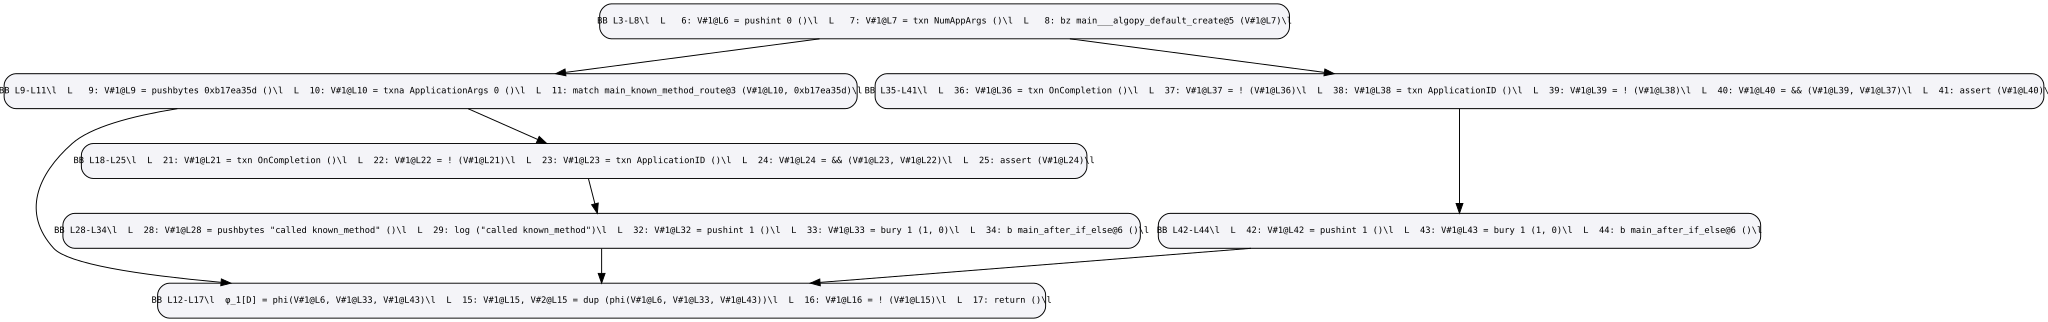

In [19]:
# Fresh program so the graph shows the live phi.
p_repro_fresh = teal_ssa.SSAProgram(REPRO)
p_repro_fresh.draw()

## 16. Constant propagation pass

`SSAProgram.propagate_constants()` walks the program once and resolves each `SSAVar` and `Phi` to a literal value when statically derivable:

- An `SSAVar` is constant when its defining `Assignment` is a constblock-pusher (`intc_*` / `bytec_*`) and the constblock entry is resolved.
- A `Phi` is constant when *every* arg (recursively, through phi chains) resolves to the **same** literal. Iterates to fixed point.

The pass attaches `.const_value` on each resolved var/phi. `Assignment.functional()` then substitutes constants for variable identifiers when rendering inputs. Pass `propagate_consts=False` to keep the raw SSA names.

Below: full xgov approval program with constants propagated. Saved to disk because the output is large (~1100 assignments).

In [20]:
# Fresh SSAProgram so the propagation runs from a clean state.
p_xgov = teal_ssa.SSAProgram(DB)

const_vars_before = sum(1 for v in p_xgov.vars.values() if v.const_value is not None)
const_phis_before = sum(1 for ph in p_xgov.phis.values() if ph.const_value is not None)
print(f"before: {const_vars_before} constant SSA vars, {const_phis_before} constant phis")

p_xgov.propagate_constants()

const_vars = sum(1 for v in p_xgov.vars.values() if v.const_value is not None)
const_phis = sum(1 for ph in p_xgov.phis.values() if ph.const_value is not None)
print(f"after:  {const_vars} constant SSA vars ({const_vars/len(p_xgov.vars):.0%} of all), "
      f"{const_phis} constant phis ({const_phis/len(p_xgov.phis):.0%} of all)")

# Render the whole program with constants substituted in inputs.
import tempfile
out_path = Path(tempfile.gettempdir()) / "teal_xgov_constprop.txt"
out_path.write_text(p_xgov.functional(file="approval.teal"))
print(f"saved: {out_path}  ({out_path.stat().st_size / 1024:.1f} KiB)")

before: 266 constant SSA vars, 0 constant phis
after:  334 constant SSA vars (39% of all), 1 constant phis (10% of all)
saved: /tmp/teal_xgov_constprop.txt  (40.6 KiB)


### Inline preview

Showing a representative slice — the entry switch (intc_0 = 0 used as comparison key) and the first prep block — so you can see propagation in action without flooding the cell.

In [21]:
print(p_xgov.functional(file="approval.teal", line_range=(1, 60)))

L   2: intcblock 0 1 10 3 ()
L   3: bytecblock 0x766f74655f74797065 0x 0x6f75616964 0x766f74655f6964 0x6f7074696f6e5f636f756e7473 0x69735f626f6f747374726170706564 0x766f7465725f636f756e74 0x636c6f73655f74696d65 0x746f74616c5f6f7074696f6e73 0x56 0x736e617073686f745f7075626c69635f6b6579 0x6d657461646174615f697066735f636964 0x73746172745f74696d65 0x656e645f74696d65 0x71756f72756d 0x6e66745f696d6167655f75726c 0x4c6bea72 0x151f7c75 0x6e66745f61737365745f6964 0x068101 0x2c ()
L   4: V#1@L4 = txn NumAppArgs ()
L   5: V#1@L5 = intc_0 ()
L   6: V#1@L6 = == (0, V#1@L4)
L   7: bnz main_l14 (V#1@L6)
L   8: V#1@L8 = txna ApplicationArgs 0 ()
L   9: V#1@L9 = pushbytes 0x101cea00 ()
L  10: V#1@L10 = == (0x101cea00, V#1@L8)
L  11: bnz main_l13 (V#1@L10)
L  12: V#1@L12 = txna ApplicationArgs 0 ()
L  13: V#1@L13 = pushbytes 0x5d4cf066 ()
L  14: V#1@L14 = == (0x5d4cf066, V#1@L12)
L  15: bnz main_l12 (V#1@L14)
L  16: V#1@L16 = txna ApplicationArgs 0 ()
L  17: V#1@L17 = pushbytes 0xa4e8d164 ()
L  18: V#1@L

### Side-by-side: with vs without propagation

In [22]:
raw  = p_xgov.functional(file="approval.teal", line_range=(35, 41), propagate_consts=False).splitlines()
prop = p_xgov.functional(file="approval.teal", line_range=(35, 41)).splitlines()
for r, q in zip(raw, prop):
    print(f"{r:<60}    {q}")

L  35: V#1@L35 = intc_0 ()                                      L  35: V#1@L35 = intc_0 ()
L  36: V#1@L36 = == (V#1@L35, V#1@L34)                          L  36: V#1@L36 = == (0, V#1@L34)
L  37: V#1@L37 = txn ApplicationID ()                           L  37: V#1@L37 = txn ApplicationID ()
L  38: V#1@L38 = intc_0 ()                                      L  38: V#1@L38 = intc_0 ()
L  39: V#1@L39 = != (V#1@L38, V#1@L37)                          L  39: V#1@L39 = != (0, V#1@L37)
L  40: V#1@L40 = && (V#1@L39, V#1@L36)                          L  40: V#1@L40 = && (V#1@L39, V#1@L36)
L  41: assert (V#1@L40)                                         L  41: assert (V#1@L40)


## 17. Unused-SSA cleanup

`SSAProgram.cleanup_unused_ssavars()` is the live Phase-C cleanup pass: after constant propagation it **drops** every side-effect-free `Assignment` whose outputs are all dead (no consumer reads any of them). Typical victims are trivial constant pushes (`L 5: V#1@L5 = 0`) whose consumers already render the inlined literal, plus duplicate reader assignments left behind by the Phase-A unification passes.

Conservative by construction: producers with side effects or source meaning (`txn` reads with effects, stores, calls) are kept even when unread.

In [23]:
# Fresh program so we can show the before / after side by side.

p_xgov_dce = teal_ssa.SSAProgram(DB)

before_count = (len(p_xgov_dce), len(p_xgov_dce.vars), len(p_xgov_dce.phis))
p_xgov_dce.propagate_constants()
p_xgov_dce.cleanup_unused_ssavars()
after_count  = (len(p_xgov_dce), len(p_xgov_dce.vars), len(p_xgov_dce.phis))

print(f"before: {before_count[0]} assignments, {before_count[1]} SSA vars, {before_count[2]} phis")
print(f"after:  {after_count[0]} assignments  ({before_count[0]-after_count[0]} dropped),")
print(f"        {after_count[1]} SSA vars     ({before_count[1]-after_count[1]} dropped),")
print(f"        {after_count[2]} phis         ({before_count[2]-after_count[2]} dropped)")

# Save the trimmed full-program trace.
import tempfile
out_path = Path(tempfile.gettempdir()) / "teal_xgov_constprop_cleanup.txt"
out_path.write_text(p_xgov_dce.functional(file="approval.teal"))
print(f"saved: {out_path}  ({out_path.stat().st_size / 1024:.1f} KiB)")

before: 1109 assignments, 860 SSA vars, 10 phis
after:  1061 assignments  (48 dropped),
        794 SSA vars     (66 dropped),
        10 phis         (0 dropped)
saved: /tmp/teal_xgov_constprop_cleanup.txt  (38.9 KiB)


### Same itoa_1 slice, before vs after cleanup

`p_xgov` (from section 16) had `propagate_constants()` only; `p_xgov_dce` has the additional cleanup pass.

In [24]:
left  = p_xgov.functional(file="approval.teal", line_range=(228, 260)).splitlines()
right = p_xgov_dce.functional(file="approval.teal", line_range=(228, 260)).splitlines()

# Right side may be shorter (some lines dropped) — pad with blanks.
width = max(len(l) for l in left)
max_lines = max(len(left), len(right))
left  += [""] * (max_lines - len(left))
right += [""] * (max_lines - len(right))

print(f"{'PROPAGATE ONLY':<{width}}    DCE")
print("-" * (width * 2 + 4))
for l, r in zip(left, right):
    print(f"{l:<{width}}    {r}")

PROPAGATE ONLY                                                                            DCE
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
L 228: proto 1 1 ()                                                                       L 228: proto 1 1 ()
L 229: V#1@L229 = pushbytes 0x30313233343536373839 ()                                     L 229: V#1@L229 = pushbytes 0x30313233343536373839 ()
L 230: V#1@L230, V#2@L230, V#3@L230 = frame_dig -1 (0x30313233343536373839, V#1@L252)     L 230: V#1@L230, V#2@L230, V#3@L230 = frame_dig -1 (0x30313233343536373839, V#1@L252)
L 231: V#1@L231 = intc_1 ()                                                               L 231: V#1@L231 = intc_1 ()
L 232: V#1@L232 = extract3 (1, V#1@L230, 0x30313233343536373839)                          L 232: V#1@L232 = extract3 (1, V#1@L230, 0x30313233343536373839)
L 233: retsub ()          